# MIT 805 Big Data Semester Project — Part 2
## Demand and Trip Economics Analysis

### Processing Objective

This analysis investigates how demand patterns relate to trip economics in New York City's
High Volume For-Hire Vehicle (HVFHV) market during 2025.

### Central Project Question

**How do demand patterns relate to trip economics and service performance in New York
City's HVFHV market during 2025?**

### Demand and Trip Economics Question

**How do passenger fares and driver compensation vary across different demand patterns
in the HVFHV market during 2025?**

The analysis will use PySpark to process the large trip-level dataset. Demand will first
be measured using trip volumes across time. The analysis will then investigate how
passenger fares, driver pay, trip distance and trip duration vary across demand conditions.

The analysis will demonstrate MapReduce-style distributed processing through:

1. **Mapping/Transformation** — creating time variables and trip-economic measures.
2. **Grouping/Shuffle** — grouping trips by meaningful time and operator keys.
3. **Reduction/Aggregation** — calculating trip counts, average fares, driver pay,
   distance and duration.
4. **Distributed Execution** — examining Spark execution plans, stages and shuffle
   operations.
5. **Visualization and Interpretation** — using reduced Spark outputs to communicate
   demand and economic patterns.

The main processing will remain in PySpark. Pandas will only be used where appropriate
for small aggregated results and final visualizations.

In [2]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
C:\Users\Lucky


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, types as T

DATA_DIR = "data/raw"
OUTPUT_DIR = "output/part2"
FIGURE_DIR = "figures/part2"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Working directory:", os.getcwd())
print("Data directory:", os.path.abspath(DATA_DIR))
print("Part 2 setup ready")

Working directory: C:\Users\Lucky
Data directory: C:\Users\Lucky\data\raw
Part 2 setup ready


In [6]:
spark = (
    SparkSession.builder
    .appName("MIT805-Part2-Demand-Economics")
    .master("local[4]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.parquet.mergeSchema", "true")
    .config("spark.sql.session.timeZone", "America/New_York")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Cores:", spark.sparkContext.defaultParallelism)

Spark version: 3.5.1
Cores: 4


In [7]:
months = range(1, 13)

paths = [
    os.path.join(
        DATA_DIR,
        f"fhvhv_tripdata_2025-{m:02d}.parquet"
    )
    for m in months
]

for path in paths:
    status = "EXISTS" if os.path.exists(path) else "MISSING"
    print(os.path.basename(path), status)

print(
    "\nFiles found:",
    sum(os.path.exists(p) for p in paths),
    "/",
    len(paths)
)

fhvhv_tripdata_2025-01.parquet EXISTS
fhvhv_tripdata_2025-02.parquet EXISTS
fhvhv_tripdata_2025-03.parquet EXISTS
fhvhv_tripdata_2025-04.parquet EXISTS
fhvhv_tripdata_2025-05.parquet EXISTS
fhvhv_tripdata_2025-06.parquet EXISTS
fhvhv_tripdata_2025-07.parquet EXISTS
fhvhv_tripdata_2025-08.parquet EXISTS
fhvhv_tripdata_2025-09.parquet EXISTS
fhvhv_tripdata_2025-10.parquet EXISTS
fhvhv_tripdata_2025-11.parquet EXISTS
fhvhv_tripdata_2025-12.parquet EXISTS

Files found: 12 / 12


In [8]:
# Load the 2025 HVFHV processing dataset
df_raw = (
    spark.read
    .option("mergeSchema", "true")
    .parquet(*paths)
)

# Select columns required for demand and trip economics
df_p2 = df_raw.select(
    "hvfhs_license_num",
    "request_datetime",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "driver_pay",
    "congestion_surcharge",
    "cbd_congestion_fee"
)

print("Columns selected:", len(df_p2.columns))
df_p2.printSchema()

Columns selected: 12
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



## 2. Map / Transformation Stage

The first stage transforms each individual trip record into variables required for
the analysis. Time features are extracted from the pickup timestamp to identify demand
patterns by month, day and hour.

Economic measures are also derived from valid trip records. These include passenger
fare per mile, driver pay per mile, driver pay per minute, and the proportion of the
base passenger fare represented by driver pay.

These transformations are performed in PySpark before any grouping or aggregation.

In [9]:
df_mapped = (
    df_p2

    # Time features
    .withColumn("pickup_date", F.to_date("pickup_datetime"))
    .withColumn("month", F.month("pickup_datetime"))
    .withColumn("day_of_week", F.date_format("pickup_datetime", "EEEE"))
    .withColumn("hour", F.hour("pickup_datetime"))

    # Convert trip time from seconds to minutes
    .withColumn(
        "trip_minutes",
        F.col("trip_time") / 60.0
    )

    # Passenger fare per mile
    .withColumn(
        "fare_per_mile",
        F.when(
            (F.col("trip_miles") > 0) &
            (F.col("base_passenger_fare") >= 0),
            F.col("base_passenger_fare") / F.col("trip_miles")
        )
    )

    # Driver pay per mile
    .withColumn(
        "driver_pay_per_mile",
        F.when(
            (F.col("trip_miles") > 0) &
            (F.col("driver_pay") > 0),
            F.col("driver_pay") / F.col("trip_miles")
        )
    )

    # Driver pay per minute
    .withColumn(
        "driver_pay_per_minute",
        F.when(
            (F.col("trip_time") > 0) &
            (F.col("driver_pay") > 0),
            F.col("driver_pay") / (F.col("trip_time") / 60.0)
        )
    )

    # Driver pay relative to base passenger fare
    .withColumn(
        "driver_pay_fare_ratio",
        F.when(
            (F.col("base_passenger_fare") > 0) &
            (F.col("driver_pay") >= 0),
            F.col("driver_pay") / F.col("base_passenger_fare")
        )
    )
)

print("Mapped columns:", len(df_mapped.columns))

df_mapped.select(
    "pickup_datetime",
    "pickup_date",
    "month",
    "day_of_week",
    "hour",
    "trip_miles",
    "trip_minutes",
    "base_passenger_fare",
    "driver_pay",
    "fare_per_mile",
    "driver_pay_per_mile",
    "driver_pay_per_minute",
    "driver_pay_fare_ratio"
).printSchema()

Mapped columns: 21
root
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- pickup_date: date (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_minutes: double (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- fare_per_mile: double (nullable = true)
 |-- driver_pay_per_mile: double (nullable = true)
 |-- driver_pay_per_minute: double (nullable = true)
 |-- driver_pay_fare_ratio: double (nullable = true)



## 3. Shuffle and Reduce Stage — Hourly Demand

Demand is measured as the number of HVFHV trips picked up during each hour of each
calendar date in 2025.

Spark groups the transformed trip records by pickup date and hour. Records with the
same date-hour key are brought together through the shuffle process, after which the
number of trips is aggregated for each group.

This converts the trip-level dataset into a much smaller hourly demand dataset that can
be used to study demand patterns and classify demand conditions.

In [10]:
hourly_demand = (
    df_mapped
    .groupBy("pickup_date", "hour")
    .agg(
        F.count("*").alias("trip_count")
    )
    .orderBy("pickup_date", "hour")
)

print("Hourly demand DataFrame created.")

Hourly demand DataFrame created.


In [11]:
n_hourly = hourly_demand.count()

print(f"Number of date-hour observations: {n_hourly:,}")

hourly_demand.show(20, truncate=False)

Number of date-hour observations: 8,760
+-----------+----+----------+
|pickup_date|hour|trip_count|
+-----------+----+----------+
|2025-01-01 |0   |56860     |
|2025-01-01 |1   |61048     |
|2025-01-01 |2   |57377     |
|2025-01-01 |3   |47302     |
|2025-01-01 |4   |32819     |
|2025-01-01 |5   |21773     |
|2025-01-01 |6   |17501     |
|2025-01-01 |7   |16159     |
|2025-01-01 |8   |14101     |
|2025-01-01 |9   |13876     |
|2025-01-01 |10  |15635     |
|2025-01-01 |11  |17950     |
|2025-01-01 |12  |19866     |
|2025-01-01 |13  |22375     |
|2025-01-01 |14  |25209     |
|2025-01-01 |15  |26897     |
|2025-01-01 |16  |25941     |
|2025-01-01 |17  |27611     |
|2025-01-01 |18  |27556     |
|2025-01-01 |19  |26278     |
+-----------+----+----------+
only showing top 20 rows



In [12]:
demand_stats = hourly_demand.select(
    F.count("*").alias("n_hours"),
    F.min("trip_count").alias("min_trips"),
    F.avg("trip_count").alias("mean_trips"),
    F.stddev("trip_count").alias("std_trips"),
    F.max("trip_count").alias("max_trips")
)

demand_stats.show()

+-------+---------+------------------+------------------+---------+
|n_hours|min_trips|        mean_trips|         std_trips|max_trips|
+-------+---------+------------------+------------------+---------+
|   8760|       85|27807.041552511415|11084.407093381833|    75292|
+-------+---------+------------------+------------------+---------+



In [13]:
percentiles = hourly_demand.approxQuantile(
    "trip_count",
    [0.10, 0.25, 0.33, 0.50, 0.67, 0.75, 0.90],
    0.001
)

labels = ["10th", "25th", "33rd", "50th", "67th", "75th", "90th"]

for label, value in zip(labels, percentiles):
    print(f"{label} percentile: {value:,.0f} trips")

10th percentile: 10,027 trips
25th percentile: 20,207 trips
33rd percentile: 25,205 trips
50th percentile: 29,902 trips
67th percentile: 33,474 trips
75th percentile: 35,236 trips
90th percentile: 40,664 trips


## 4. Demand Classification

Hourly demand was classified using tertiles of the observed 2025 hourly trip-count
distribution. This data-driven approach avoids selecting arbitrary demand thresholds
and creates approximately balanced groups for comparison.

The 33rd percentile was 25,205 trips per hour and the 67th percentile was 33,474 trips
per hour.

- **Low demand:** 25,205 trips per hour or fewer
- **Medium demand:** more than 25,205 and up to 33,474 trips per hour
- **High demand:** more than 33,474 trips per hour

The classification applies to individual date-hour observations rather than treating
particular clock hours as permanently high or low demand.

In [14]:
low_cut = percentiles[2]     # 33rd percentile
high_cut = percentiles[4]    # 67th percentile

hourly_classified = (
    hourly_demand
    .withColumn(
        "demand_level",
        F.when(
            F.col("trip_count") <= low_cut,
            "Low"
        )
        .when(
            F.col("trip_count") <= high_cut,
            "Medium"
        )
        .otherwise("High")
    )
)

print(f"Low-demand cutoff:  {low_cut:,.0f}")
print(f"High-demand cutoff: {high_cut:,.0f}")

Low-demand cutoff:  25,205
High-demand cutoff: 33,474


In [15]:
demand_level_summary = (
    hourly_classified
    .groupBy("demand_level")
    .agg(
        F.count("*").alias("n_hours"),
        F.min("trip_count").alias("min_trips"),
        F.avg("trip_count").alias("avg_trips"),
        F.max("trip_count").alias("max_trips")
    )
    .orderBy(
        F.when(F.col("demand_level") == "Low", 1)
         .when(F.col("demand_level") == "Medium", 2)
         .otherwise(3)
    )
)

demand_level_summary.show()

+------------+-------+---------+------------------+---------+
|demand_level|n_hours|min_trips|         avg_trips|max_trips|
+------------+-------+---------+------------------+---------+
|         Low|   2884|       85|14478.363037447989|    25205|
|      Medium|   2982|    25207|29800.943326626424|    33474|
|        High|   2894|    33476| 39035.13199723566|    75292|
+------------+-------+---------+------------------+---------+



## 5. Joining Demand Conditions to Trip Records

The hourly demand classification is joined back to the trip-level dataset using
pickup date and pickup hour as the join keys.

This assigns each individual trip a Low, Medium or High demand label according to
the number of HVFHV trips occurring during that date-hour.

The resulting dataset allows trip economics to be compared across different demand
conditions while retaining the original trip-level information.

In [16]:
# Only keep the fields required from the hourly table
demand_lookup = hourly_classified.select(
    "pickup_date",
    "hour",
    "trip_count",
    "demand_level"
)

# Join demand conditions back onto individual trips
trips_with_demand = (
    df_mapped
    .join(
        F.broadcast(demand_lookup),
        on=["pickup_date", "hour"],
        how="left"
    )
)

print("Demand classification joined to trip-level data.")

Demand classification joined to trip-level data.


## 6. Trip Economics by Demand Level

The trip-level dataset is aggregated by demand level to compare trip characteristics
and economic measures under Low, Medium and High demand conditions.

The analysis compares passenger fare, driver pay, trip distance, trip duration and
derived per-unit measures. This helps determine whether higher market demand is
associated with different trip economics.

In [17]:
economics_by_demand = (
    trips_with_demand
    .groupBy("demand_level")
    .agg(
        F.count("*").alias("n_trips"),

        F.avg("trip_miles").alias("avg_trip_miles"),
        F.avg("trip_minutes").alias("avg_trip_minutes"),

        F.avg("base_passenger_fare").alias("avg_base_fare"),
        F.avg("driver_pay").alias("avg_driver_pay"),

        F.avg("fare_per_mile").alias("avg_fare_per_mile"),
        F.avg("driver_pay_per_mile").alias("avg_driver_pay_per_mile"),
        F.avg("driver_pay_per_minute").alias("avg_driver_pay_per_minute"),
        F.avg("driver_pay_fare_ratio").alias("avg_driver_pay_fare_ratio")
    )
)

economics_by_demand.show(truncate=False)

+------------+---------+-----------------+------------------+------------------+------------------+-----------------+-----------------------+-------------------------+-------------------------+
|demand_level|n_trips  |avg_trip_miles   |avg_trip_minutes  |avg_base_fare     |avg_driver_pay    |avg_fare_per_mile|avg_driver_pay_per_mile|avg_driver_pay_per_minute|avg_driver_pay_fare_ratio|
+------------+---------+-----------------+------------------+------------------+------------------+-----------------+-----------------------+-------------------------+-------------------------+
|High        |112967672|4.677975219388409|20.42324482411793 |26.897012561340766|20.891432771753337|8.321355596273431|6.017255272348126      |1.019643434592016        |0.7950890896653304       |
|Medium      |88866413 |5.028864859257847|20.13131232456358 |27.085177891218713|20.816052555533393|7.698899304855588|5.515206487044942      |1.0133467507739564       |0.7835530410404897       |
|Low         |41755599 |6.0014

In [18]:
economics_valid = (
    trips_with_demand
    .filter(
        (F.col("trip_miles") >= 0.1) &
        (F.col("trip_time") > 0) &
        (F.col("trip_time") <= 6 * 3600) &
        (F.col("base_passenger_fare") >= 0) &
        (F.col("driver_pay") > 0)
    )
)

print("Economics-valid DataFrame defined.")

Economics-valid DataFrame defined.


In [19]:
thresholds = [0.0, 0.1, 0.5]

sensitivity_results = []

for threshold in thresholds:
    result = (
        trips_with_demand
        .filter(
            (F.col("trip_miles") > threshold) &
            (F.col("trip_time") > 0) &
            (F.col("trip_time") <= 6 * 3600) &
            (F.col("base_passenger_fare") >= 0) &
            (F.col("driver_pay") > 0)
        )
        .groupBy("demand_level")
        .agg(
            F.count("*").alias("n_trips"),
            F.avg(
                F.col("base_passenger_fare") / F.col("trip_miles")
            ).alias("avg_fare_per_mile"),
            F.avg(
                F.col("driver_pay") / F.col("trip_miles")
            ).alias("avg_driver_pay_per_mile")
        )
        .withColumn("min_miles", F.lit(threshold))
    )

    sensitivity_results.append(result)

sensitivity = sensitivity_results[0]

for result in sensitivity_results[1:]:
    sensitivity = sensitivity.unionByName(result)

sensitivity.orderBy("min_miles", "demand_level").show(
    20,
    truncate=False
)

+------------+---------+-----------------+-----------------------+---------+
|demand_level|n_trips  |avg_fare_per_mile|avg_driver_pay_per_mile|min_miles|
+------------+---------+-----------------+-----------------------+---------+
|High        |112924145|8.296240788884521|6.015529370359191      |0.0      |
|Low         |41740151 |6.29889201739839 |4.535258726443572      |0.0      |
|Medium      |88831316 |7.674907751347292|5.5131989176121445     |0.0      |
|High        |112900018|8.178700224978991|5.93820395168608       |0.1      |
|Low         |41731284 |6.167592973192376|4.4501863386422436     |0.1      |
|Medium      |88813184 |7.568663615148126|5.444448210725967      |0.1      |
|High        |111379396|7.944413111178023|5.801582184129077      |0.5      |
|Low         |41297830 |5.991728025945028|4.347612545190297      |0.5      |
|Medium      |87658537 |7.355736542175891|5.325533824820465      |0.5      |
+------------+---------+-----------------+-----------------------+---------+

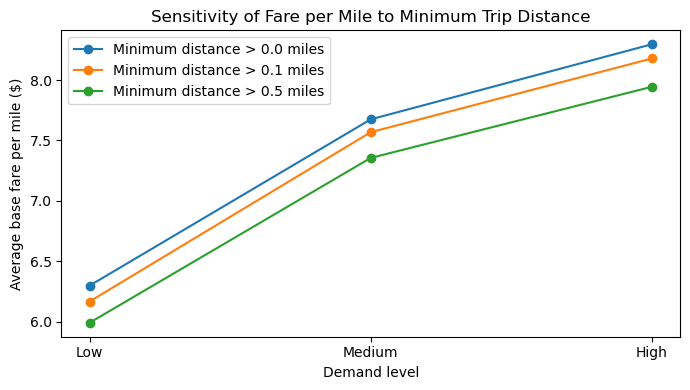

saved figures/fig1_fare_per_mile_sensitivity.png


In [23]:
#aggregated result 
sensitivity_pd = (
    sensitivity
    .orderBy("min_miles", "demand_level")
    .toPandas()
)

demand_order = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(7, 4))

for threshold in [0.0, 0.1, 0.5]:
    subset = (
        sensitivity_pd[
            sensitivity_pd["min_miles"] == threshold
        ]
        .set_index("demand_level")
        .loc[demand_order]
    )

    ax.plot(
        demand_order,
        subset["avg_fare_per_mile"],
        marker="o",
        label=f"Minimum distance > {threshold} miles"
    )

ax.set_xlabel("Demand level")
ax.set_ylabel("Average base fare per mile ($)")
ax.set_title("Sensitivity of Fare per Mile to Minimum Trip Distance")
ax.legend()

fig.tight_layout()

fig.savefig(
    "figures/fig1_fare_per_mile_sensitivity.png",
    dpi=300
)

plt.show()

print("saved figures/fig1_fare_per_mile_sensitivity.png")

In [24]:
df_p2.groupBy("hvfhs_license_num").count().orderBy(
    F.desc("count")
).show()

+-----------------+---------+
|hvfhs_license_num|    count|
+-----------------+---------+
|           HV0003|175989546|
|           HV0005| 67600138|
+-----------------+---------+



## 7. Operator-Level Comparison

The analysis is extended by separating trips according to HVFHV licence number.
This tests whether the relationship between demand conditions and trip economics is
consistent across operators rather than being driven by changes in the overall market mix.

Economic comparisons use the analysis-valid dataset, which requires positive driver pay,
non-negative base passenger fare, valid trip duration, and a minimum trip distance of
0.1 miles.

In [25]:
operator_demand = (
    economics_valid
    .groupBy(
        "hvfhs_license_num",
        "demand_level"
    )
    .agg(
        F.count("*").alias("n_trips"),

        F.avg("trip_miles").alias("avg_trip_miles"),
        F.avg("trip_minutes").alias("avg_trip_minutes"),

        F.avg("base_passenger_fare").alias("avg_base_fare"),
        F.avg("driver_pay").alias("avg_driver_pay"),

        F.avg("fare_per_mile").alias("avg_fare_per_mile"),
        F.avg("driver_pay_per_mile").alias("avg_driver_pay_per_mile")
    )
    .orderBy(
        "hvfhs_license_num",
        "demand_level"
    )
)

operator_demand.show(10, truncate=False)

+-----------------+------------+--------+-----------------+------------------+------------------+------------------+------------------+-----------------------+
|hvfhs_license_num|demand_level|n_trips |avg_trip_miles   |avg_trip_minutes  |avg_base_fare     |avg_driver_pay    |avg_fare_per_mile |avg_driver_pay_per_mile|
+-----------------+------------+--------+-----------------+------------------+------------------+------------------+------------------+-----------------------+
|HV0003           |High        |82243224|4.770222659194425|20.528552242593697|27.642426037310145|21.317884861733862|8.372036942920005 |6.005901963339833      |
|HV0003           |Low         |29224902|6.091519738885684|17.889956132843963|27.475411316692036|20.886388759833434|6.319252989343346 |4.477928607462635      |
|HV0003           |Medium      |64396714|5.089802378580951|20.143284108668514|27.7981281057281  |21.072354533027628|7.768682427381905 |5.4811598504682735     |
|HV0005           |High        |30658616

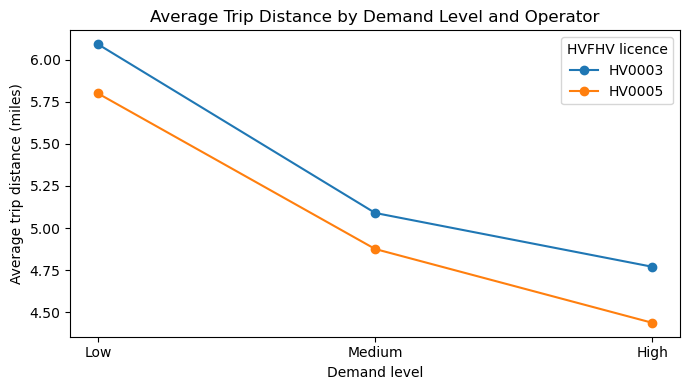

saved figures/fig_p2_02_distance_by_demand_operator.png


In [26]:
operator_pd = operator_demand.toPandas()

demand_order = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(7, 4))

for licence in sorted(operator_pd["hvfhs_license_num"].unique()):
    subset = (
        operator_pd[
            operator_pd["hvfhs_license_num"] == licence
        ]
        .set_index("demand_level")
        .loc[demand_order]
    )

    ax.plot(
        demand_order,
        subset["avg_trip_miles"],
        marker="o",
        label=licence
    )

ax.set_xlabel("Demand level")
ax.set_ylabel("Average trip distance (miles)")
ax.set_title("Average Trip Distance by Demand Level and Operator")
ax.legend(title="HVFHV licence")

fig.tight_layout()

fig.savefig(
    "figures/fig_p2_02_distance_by_demand_operator.png",
    dpi=300
)

plt.show()

print("saved figures/fig_p2_02_distance_by_demand_operator.png")

## 8. Temporal Demand Patterns

To understand when different demand conditions occur, hourly demand is summarized by
hour of day and day of week. This provides context for the economic differences observed
between Low, Medium and High demand periods.

In [27]:
demand_by_hour = (
    hourly_classified
    .groupBy("hour")
    .agg(
        F.avg("trip_count").alias("avg_hourly_trips"),
        F.min("trip_count").alias("min_hourly_trips"),
        F.max("trip_count").alias("max_hourly_trips")
    )
    .orderBy("hour")
)

demand_by_hour.show(24, truncate=False)

+----+------------------+----------------+----------------+
|hour|avg_hourly_trips  |min_hourly_trips|max_hourly_trips|
+----+------------------+----------------+----------------+
|0   |23873.471232876713|12174           |56860           |
|1   |16709.057534246575|6841            |75292           |
|2   |11966.04109589041 |85              |57377           |
|3   |9699.34794520548  |4158            |47302           |
|4   |10255.230136986302|6456            |32819           |
|5   |12182.764383561644|7550            |21773           |
|6   |18764.386301369865|10080           |24719           |
|7   |27931.80821917808 |12796           |39912           |
|8   |34229.923287671234|12723           |55062           |
|9   |31947.23287671233 |13683           |50840           |
|10  |29288.098630136985|15635           |39978           |
|11  |28685.66575342466 |17950           |40336           |
|12  |29243.690410958905|19866           |42212           |
|13  |30263.29315068493 |22375          

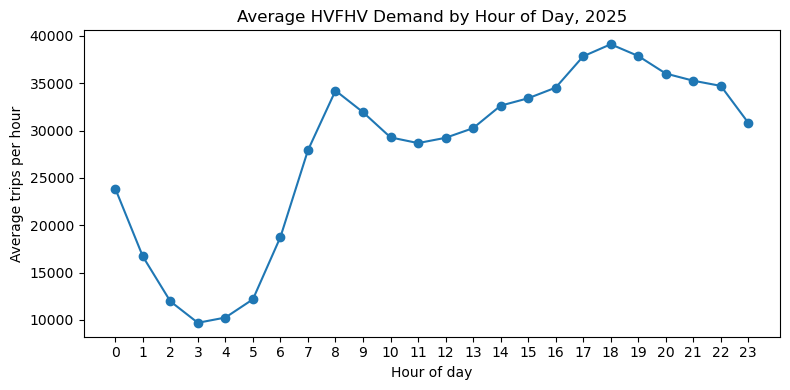

saved figures/fig_p2_03_demand_by_hour.png


In [28]:
hour_pd = demand_by_hour.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    hour_pd["hour"],
    hour_pd["avg_hourly_trips"],
    marker="o"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Average trips per hour")
ax.set_title("Average HVFHV Demand by Hour of Day, 2025")

ax.set_xticks(range(0, 24))

fig.tight_layout()

fig.savefig(
    "figures/fig_p2_03_demand_by_hour.png",
    dpi=300
)

plt.show()

print("saved figures/fig_p2_03_demand_by_hour.png")

In [29]:
weekday_demand = (
    hourly_classified
    .withColumn(
        "day_of_week",
        F.date_format("pickup_date", "EEEE")
    )
    .groupBy("day_of_week")
    .agg(
        F.avg("trip_count").alias("avg_hourly_trips"),
        F.min("trip_count").alias("min_hourly_trips"),
        F.max("trip_count").alias("max_hourly_trips")
    )
)

weekday_demand.show(truncate=False)

+-----------+------------------+----------------+----------------+
|day_of_week|avg_hourly_trips  |min_hourly_trips|max_hourly_trips|
+-----------+------------------+----------------+----------------+
|Sunday     |27568.728365384617|85              |75292           |
|Wednesday  |27007.686320754718|4589            |65380           |
|Saturday   |31995.952724358973|7290            |56887           |
|Friday     |30382.08012820513 |6105            |59253           |
|Thursday   |28084.55048076923 |5058            |49114           |
|Tuesday    |25330.07532051282 |4158            |48655           |
|Monday     |24295.589743589742|4910            |46322           |
+-----------+------------------+----------------+----------------+



In [30]:
weekday_hour = (
    hourly_classified
    .withColumn(
        "day_of_week",
        F.date_format("pickup_date", "EEEE")
    )
    .groupBy("day_of_week", "hour")
    .agg(
        F.avg("trip_count").alias("avg_hourly_trips")
    )
    .orderBy("day_of_week", "hour")
)

weekday_hour.show(30, truncate=False)

+-----------+----+------------------+
|day_of_week|hour|avg_hourly_trips  |
+-----------+----+------------------+
|Friday     |0   |23429.44230769231 |
|Friday     |1   |15169.442307692309|
|Friday     |2   |10128.692307692309|
|Friday     |3   |8211.73076923077  |
|Friday     |4   |9837.096153846154 |
|Friday     |5   |12950.846153846154|
|Friday     |6   |20863.96153846154 |
|Friday     |7   |32052.28846153846 |
|Friday     |8   |38855.153846153844|
|Friday     |9   |33972.269230769234|
|Friday     |10  |30063.326923076922|
|Friday     |11  |29245.23076923077 |
|Friday     |12  |30166.21153846154 |
|Friday     |13  |31373.71153846154 |
|Friday     |14  |34235.0           |
|Friday     |15  |34891.519230769234|
|Friday     |16  |36761.36538461538 |
|Friday     |17  |40887.942307692305|
|Friday     |18  |43899.32692307692 |
|Friday     |19  |44447.403846153844|
|Friday     |20  |41661.557692307695|
|Friday     |21  |40708.057692307695|
|Friday     |22  |43231.61538461538 |
|Friday     

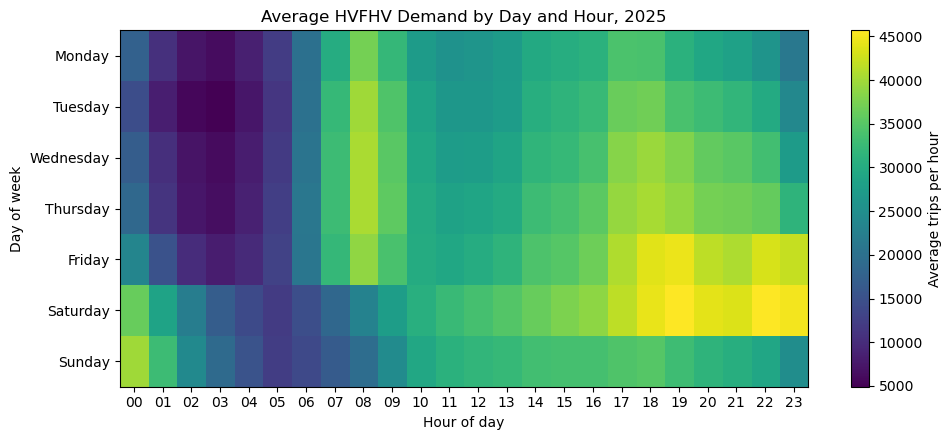

saved figures/fig_p2_04_weekday_hour_heatmap.png


In [31]:
weekday_hour_pd = weekday_hour.toPandas()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = (
    weekday_hour_pd
    .pivot(
        index="day_of_week",
        columns="hour",
        values="avg_hourly_trips"
    )
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])

ax.set_yticks(range(len(day_order)))
ax.set_yticklabels(day_order)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Average HVFHV Demand by Day and Hour, 2025")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average trips per hour")

fig.tight_layout()

fig.savefig(
    "figures/fig_p2_04_weekday_hour_heatmap.png",
    dpi=300
)

plt.show()

print("saved figures/fig_p2_04_weekday_hour_heatmap.png")

## 9. Distributed Execution Evidence

Spark uses lazy evaluation to build a Directed Acyclic Graph (DAG) of transformations.
An action triggers execution of this plan. The physical execution plan below is used
to identify transformations, partition exchanges (shuffle), and aggregation stages
in the hourly demand calculation.

In [32]:
hourly_demand.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (8)
+- Sort (7)
   +- Exchange (6)
      +- HashAggregate (5)
         +- Exchange (4)
            +- HashAggregate (3)
               +- Project (2)
                  +- Scan parquet  (1)


(1) Scan parquet 
Output [1]: [pickup_datetime#5]
Batched: true
Location: InMemoryFileIndex [file:/C:/Users/Lucky/data/raw/fhvhv_tripdata_2025-01.parquet, ... 11 entries]
ReadSchema: struct<pickup_datetime:timestamp_ntz>

(2) Project
Output [2]: [cast(pickup_datetime#5 as date) AS pickup_date#63, hour(pickup_datetime#5, Some(America/New_York)) AS hour#108]
Input [1]: [pickup_datetime#5]

(3) HashAggregate
Input [2]: [pickup_date#63, hour#108]
Keys [2]: [pickup_date#63, hour#108]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#281L]
Results [3]: [pickup_date#63, hour#108, count#282L]

(4) Exchange
Input [3]: [pickup_date#63, hour#108, count#282L]
Arguments: hashpartitioning(pickup_date#63, hour#108, 32), ENSURE_REQUIREMENTS, [plan_id=6904]

(5

In [33]:
economics_by_demand.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (16)
+- HashAggregate (15)
   +- Exchange (14)
      +- HashAggregate (13)
         +- Project (12)
            +- BroadcastHashJoin LeftOuter BuildRight (11)
               :- Project (2)
               :  +- Scan parquet  (1)
               +- BroadcastExchange (10)
                  +- Project (9)
                     +- HashAggregate (8)
                        +- Exchange (7)
                           +- HashAggregate (6)
                              +- Project (5)
                                 +- Filter (4)
                                    +- Scan parquet  (3)


(1) Scan parquet 
Output [5]: [pickup_datetime#5, trip_miles#9, trip_time#10L, base_passenger_fare#11, driver_pay#18]
Batched: true
Location: InMemoryFileIndex [file:/C:/Users/Lucky/data/raw/fhvhv_tripdata_2025-01.parquet, ... 11 entries]
ReadSchema: struct<pickup_datetime:timestamp_ntz,trip_miles:double,trip_time:bigint,base_passenger_fare:double,driver_pay:double>

(2) Proje

### Spark DAG vs Traditional Hadoop MapReduce

The analysis follows the MapReduce idea of mapping records into useful features,
grouping or shuffling records with common keys, and reducing them through aggregation.

However, Spark does not execute the analysis as a single fixed Map → Shuffle → Reduce
sequence. Spark builds a Directed Acyclic Graph (DAG) containing multiple connected
transformations. When an action is requested, Spark optimises this plan and divides it
into execution stages, with shuffle operations creating important stage boundaries.

For example, the hourly-demand pipeline first transforms pickup timestamps into date
and hour keys, performs partial counts, shuffles records by those keys, and completes
the final aggregation. The trip-economics pipeline additionally uses a broadcast hash
join to attach the small hourly demand table to the much larger trip-level dataset
before performing further distributed aggregations.

In [34]:
ZONE_LOOKUP = "data/raw/taxi_zone_lookup.csv"

print("Zone lookup exists:", os.path.exists(ZONE_LOOKUP))
print("Path:", os.path.abspath(ZONE_LOOKUP))

Zone lookup exists: True
Path: C:\Users\Lucky\data\raw\taxi_zone_lookup.csv


In [35]:
zones = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(ZONE_LOOKUP)
)

zones.printSchema()
zones.show(10, truncate=False)

root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

+----------+-------------+-----------------------+------------+
|LocationID|Borough      |Zone                   |service_zone|
+----------+-------------+-----------------------+------------+
|1         |EWR          |Newark Airport         |EWR         |
|2         |Queens       |Jamaica Bay            |Boro Zone   |
|3         |Bronx        |Allerton/Pelham Gardens|Boro Zone   |
|4         |Manhattan    |Alphabet City          |Yellow Zone |
|5         |Staten Island|Arden Heights          |Boro Zone   |
|6         |Staten Island|Arrochar/Fort Wadsworth|Boro Zone   |
|7         |Queens       |Astoria                |Boro Zone   |
|8         |Queens       |Astoria Park           |Boro Zone   |
|9         |Queens       |Auburndale             |Boro Zone   |
|10        |Queens       |Baisley Park           |Boro Zone   |


## 10. Spatial Demand Analysis

Spatial demand is analysed using the TLC pickup location identifier (`PULocationID`).
Trip records are first aggregated by pickup zone and demand level. The TLC Taxi Zone
lookup is then used to attach readable borough and zone names.

This analysis identifies where HVFHV trips originate and whether the spatial
distribution of trips differs between Low, Medium and High demand conditions.

In [36]:
zone_demand = (
    trips_with_demand
    .groupBy(
        "PULocationID",
        "demand_level"
    )
    .agg(
        F.count("*").alias("n_trips"),
        F.avg("trip_miles").alias("avg_trip_miles"),
        F.avg("base_passenger_fare").alias("avg_base_fare"),
        F.avg("driver_pay").alias("avg_driver_pay")
    )
)

print("Zone-demand aggregation defined.")

Zone-demand aggregation defined.


In [37]:
zone_demand_named = (
    zone_demand
    .join(
        F.broadcast(zones),
        zone_demand["PULocationID"] == zones["LocationID"],
        "left"
    )
    .select(
        "PULocationID",
        "Borough",
        "Zone",
        "demand_level",
        "n_trips",
        "avg_trip_miles",
        "avg_base_fare",
        "avg_driver_pay"
    )
)

busiest_zones = (
    zone_demand_named
    .groupBy(
        "PULocationID",
        "Borough",
        "Zone"
    )
    .agg(
        F.sum("n_trips").alias("total_trips")
    )
    .orderBy(F.desc("total_trips"))
)

busiest_zones.show(15, truncate=False)

+------------+---------+-------------------------+-----------+
|PULocationID|Borough  |Zone                     |total_trips|
+------------+---------+-------------------------+-----------+
|138         |Queens   |LaGuardia Airport        |4923107    |
|132         |Queens   |JFK Airport              |4068926    |
|61          |Brooklyn |Crown Heights North      |3165225    |
|230         |Manhattan|Times Sq/Theatre District|2898426    |
|79          |Manhattan|East Village             |2897628    |
|161         |Manhattan|Midtown Center           |2820283    |
|76          |Brooklyn |East New York            |2718688    |
|37          |Brooklyn |Bushwick South           |2691982    |
|231         |Manhattan|TriBeCa/Civic Center     |2651787    |
|68          |Manhattan|East Chelsea             |2537812    |
|234         |Manhattan|Union Sq                 |2527548    |
|246         |Manhattan|West Chelsea/Hudson Yards|2506681    |
|255         |Brooklyn |Williamsburg (North Side)|24435

In [38]:
borough_demand = (
    zone_demand_named
    .filter(F.col("Borough").isNotNull())
    .groupBy("Borough")
    .agg(
        F.sum("n_trips").alias("total_trips")
    )
    .orderBy(F.desc("total_trips"))
)

borough_demand.show(truncate=False)

+-------------+-----------+
|Borough      |total_trips|
+-------------+-----------+
|Manhattan    |90159564   |
|Brooklyn     |65312344   |
|Queens       |52891452   |
|Bronx        |31406031   |
|Staten Island|3809881    |
|N/A          |10393      |
|EWR          |14         |
|Unknown      |5          |
+-------------+-----------+



In [39]:
borough_demand_level = (
    zone_demand_named
    .filter(F.col("Borough").isNotNull())
    .groupBy(
        "Borough",
        "demand_level"
    )
    .agg(
        F.sum("n_trips").alias("n_trips")
    )
    .orderBy(
        "Borough",
        "demand_level"
    )
)

borough_demand_level.show(30, truncate=False)

+-------------+------------+--------+
|Borough      |demand_level|n_trips |
+-------------+------------+--------+
|Bronx        |High        |14280766|
|Bronx        |Low         |5617330 |
|Bronx        |Medium      |11507935|
|Brooklyn     |High        |30746049|
|Brooklyn     |Low         |11156188|
|Brooklyn     |Medium      |23410107|
|EWR          |High        |7       |
|EWR          |Low         |2       |
|EWR          |Medium      |5       |
|Manhattan    |High        |43054942|
|Manhattan    |Low         |14400673|
|Manhattan    |Medium      |32703949|
|N/A          |High        |4646    |
|N/A          |Low         |1872    |
|N/A          |Medium      |3875    |
|Queens       |High        |23139655|
|Queens       |Low         |9969953 |
|Queens       |Medium      |19781844|
|Staten Island|High        |1741604 |
|Staten Island|Low         |609580  |
|Staten Island|Medium      |1458697 |
|Unknown      |High        |3       |
|Unknown      |Low         |1       |
|Unknown    

### Spatial Composition of Demand

To compare spatial patterns fairly across demand levels, borough trip counts are converted
to percentages within each demand category. This shows whether the geographic composition
of realized demand changes between Low, Medium and High demand periods rather than simply
reflecting the larger number of trips occurring during high-demand hours.

In [40]:
main_boroughs = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

borough_share = (
    borough_demand_level
    .filter(F.col("Borough").isin(main_boroughs))
)

demand_totals = (
    borough_share
    .groupBy("demand_level")
    .agg(F.sum("n_trips").alias("demand_total"))
)

borough_share = (
    borough_share
    .join(demand_totals, on="demand_level", how="left")
    .withColumn(
        "trip_share_pct",
        F.col("n_trips") / F.col("demand_total") * 100
    )
    .select(
        "Borough",
        "demand_level",
        "n_trips",
        F.round("trip_share_pct", 2).alias("trip_share_pct")
    )
    .orderBy("demand_level", F.desc("trip_share_pct"))
)

borough_share.show(20, truncate=False)

+-------------+------------+--------+--------------+
|Borough      |demand_level|n_trips |trip_share_pct|
+-------------+------------+--------+--------------+
|Manhattan    |High        |43054942|38.11         |
|Brooklyn     |High        |30746049|27.22         |
|Queens       |High        |23139655|20.48         |
|Bronx        |High        |14280766|12.64         |
|Staten Island|High        |1741604 |1.54          |
|Manhattan    |Low         |14400673|34.49         |
|Brooklyn     |Low         |11156188|26.72         |
|Queens       |Low         |9969953 |23.88         |
|Bronx        |Low         |5617330 |13.45         |
|Staten Island|Low         |609580  |1.46          |
|Manhattan    |Medium      |32703949|36.8          |
|Brooklyn     |Medium      |23410107|26.34         |
|Queens       |Medium      |19781844|22.26         |
|Bronx        |Medium      |11507935|12.95         |
|Staten Island|Medium      |1458697 |1.64          |
+-------------+------------+--------+---------

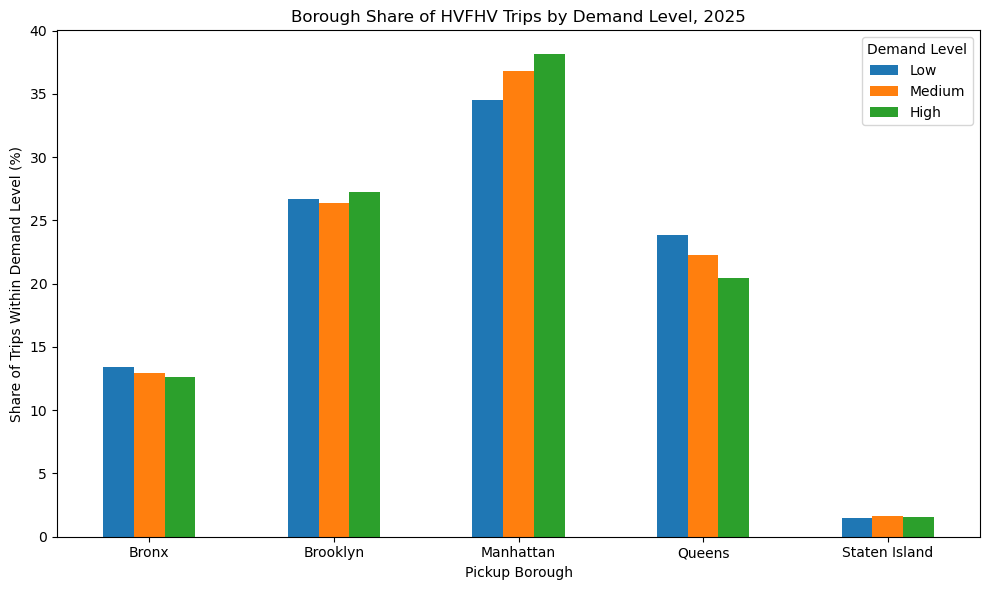

In [41]:
borough_share_pd = borough_share.toPandas()

demand_order = ["Low", "Medium", "High"]

borough_pivot = (
    borough_share_pd
    .pivot(
        index="Borough",
        columns="demand_level",
        values="trip_share_pct"
    )
    .reindex(main_boroughs)
    [demand_order]
)

ax = borough_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Borough Share of HVFHV Trips by Demand Level, 2025")
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Share of Trips Within Demand Level (%)")
ax.legend(title="Demand Level")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "figures/fig_p2_05_borough_share_by_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
zone_share_base = (
    zone_demand_named
    .filter(
        F.col("Borough").isin(main_boroughs) &
        F.col("Zone").isNotNull() &
        F.col("demand_level").isin(["Low", "High"])
    )
    .select(
        "PULocationID",
        "Borough",
        "Zone",
        "demand_level",
        "n_trips"
    )
)

zone_level_totals = (
    zone_share_base
    .groupBy("demand_level")
    .agg(F.sum("n_trips").alias("demand_total"))
)

zone_shares = (
    zone_share_base
    .join(zone_level_totals, "demand_level")
    .withColumn(
        "trip_share_pct",
        F.col("n_trips") / F.col("demand_total") * 100
    )
)

In [44]:
zone_shift = (
    zone_shares
    .groupBy(
        "PULocationID",
        "Borough",
        "Zone"
    )
    .pivot("demand_level", ["Low", "High"])
    .agg(F.first("trip_share_pct"))
    .fillna(0)
    .withColumn(
        "share_change_pp",
        F.col("High") - F.col("Low")
    )
)

In [45]:
print("Zones gaining the most share during High-demand periods:")

zone_shift.orderBy(
    F.desc("share_change_pp")
).select(
    "Borough",
    "Zone",
    F.round("Low", 3).alias("Low_share_pct"),
    F.round("High", 3).alias("High_share_pct"),
    F.round("share_change_pp", 3).alias("change_pp")
).show(15, truncate=False)

Zones gaining the most share during High-demand periods:
+---------+-----------------------------+-------------+--------------+---------+
|Borough  |Zone                         |Low_share_pct|High_share_pct|change_pp|
+---------+-----------------------------+-------------+--------------+---------+
|Manhattan|West Chelsea/Hudson Yards    |0.711        |1.134         |0.423    |
|Manhattan|Upper East Side South        |0.482        |0.891         |0.409    |
|Manhattan|TriBeCa/Civic Center         |0.82         |1.198         |0.379    |
|Manhattan|Upper East Side North        |0.428        |0.746         |0.319    |
|Queens   |LaGuardia Airport            |1.472        |1.784         |0.312    |
|Manhattan|Midtown Center               |0.888        |1.191         |0.303    |
|Manhattan|Union Sq                     |0.822        |1.116         |0.295    |
|Brooklyn |Park Slope                   |0.787        |1.05          |0.263    |
|Brooklyn |Greenpoint                   |0.87       

In [46]:
print("Zones losing the most share during High-demand periods:")

zone_shift.orderBy(
    F.asc("share_change_pp")
).select(
    "Borough",
    "Zone",
    F.round("Low", 3).alias("Low_share_pct"),
    F.round("High", 3).alias("High_share_pct"),
    F.round("share_change_pp", 3).alias("change_pp")
).show(15, truncate=False)

Zones losing the most share during High-demand periods:
+---------+-------------------------+-------------+--------------+---------+
|Borough  |Zone                     |Low_share_pct|High_share_pct|change_pp|
+---------+-------------------------+-------------+--------------+---------+
|Queens   |JFK Airport              |2.182        |1.399         |-0.783   |
|Brooklyn |Bushwick South           |1.53         |1.048         |-0.483   |
|Brooklyn |Bushwick North           |1.19         |0.751         |-0.438   |
|Manhattan|Lower East Side          |1.322        |0.974         |-0.348   |
|Queens   |Jackson Heights          |1.055        |0.719         |-0.336   |
|Manhattan|Clinton East             |1.206        |0.88          |-0.326   |
|Manhattan|East Village             |1.485        |1.224         |-0.261   |
|Queens   |Maspeth                  |0.544        |0.288         |-0.255   |
|Brooklyn |East Williamsburg        |1.035        |0.785         |-0.25    |
|Queens   |Astoria  